# Buổi 8: Bài toán phân cụm

In [4]:
import numpy as np
import random, os
from IPython import display

import matplotlib.pyplot as plt          # vẽ hình
from collections import Counter

import pandas as pd
from sklearn.datasets import make_blobs  # tạo tập điểm phân bố Gaussian
from sklearn.cluster import KMeans       # thuật toán phân cụm k-means

import warnings
warnings.filterwarnings("ignore")

# cố định random-state để phục hồi lại kết quả thí nghiệm
random_state = 42
random.seed(random_state)
os.environ['PYTHONHASHSEED'] = str(random_state)
np.random.seed(random_state)

## Bài 1. Tập hợp điểm hai chiều

### 1. Tạo và hiển thị dữ liệu

Tạo và hiển thị tập hợp điểm dữ liệu $X_1$ có chứa $N=400$ điểm hai chiều. Những tập hợp này bao gồm 4 nhóm bằng nhau, mỗi nhóm có hàm mật độ theo phân phối Gaussian với mean $m_0=\left(0, 0\right)$, $m_1=\left(10, 0\right)$, $m_2=\left(0, 9\right)$, và $m_3=\left(9, 8\right)$ và ma trận covariance tương ứng $S_0=I$, $S_1=1.5I$, $S_2=1.1I$, và $S_3=0.5I$ nơi mà $
I = \begin{bmatrix}
 1 & 1\\ 
 1 & 1
\end{bmatrix}.
$

**Lưu ý**: 
+ **mean** là tâm của tập hợp điểm
+ **covariance** cho biết độ biến đổi của tập điểm xung quanh tâm. Giá trị càng lớn thì độ phân tán so với tâm càng xa và ngược lại.

In [2]:
# Sinh tập hợp điểm theo phân phối Gaussian
X1, y1 = make_blobs(n_samples    = 400,                         # số lượng điểm
                    centers      = [[0,0], [10,0],[0,9],[9,8]], # vị trí tâm
                    cluster_std  = [1, 1.5, 1.1, 0.5],          # độ phân tán
                    random_state = random_state,                # seed ngẫu nhiên
                   )

In [3]:
# lưu trữ trong pandas
df_points = pd.DataFrame(X1, columns=["x", "y"])
df_points["label"] = y1

# tính số lớp, tần số xuất hiện mỗi lớp
n_classes = len(np.unique(df_points["label"])) # tính số lớp dữ liệu
labels, cnts = np.unique(df_points["label"], return_counts=True)
n_cnts = dict(zip(labels, cnts))
print(f'+ labels={labels}\n+ cnts={cnts}\n+ n_cnts={n_cnts}')

# hiển thị dữ liệu
display.display(df_points)

+ labels=[0 1 2 3]
+ cnts=[100 100 100 100]
+ n_cnts={0: 100, 1: 100, 2: 100, 3: 100}


,x,y,label
0,0.372346,8.543183,2
1,-0.495072,9.685135,2
2,8.738638,8.524505,3
3,9.014159,8.014878,3
4,8.505198,7.937107,3
...,...,...,...
395,11.120940,0.915555,1
396,11.022929,-0.465400,1
397,-1.150994,0.375698,0
398,-2.718809,8.123415,2


Center 0: [-0.11556425  0.03402232]
Center 1: [10.19237309  0.06523147]
Center 2: [-0.04954113  8.86110005]
Center 3: [8.96175896 8.04720768]


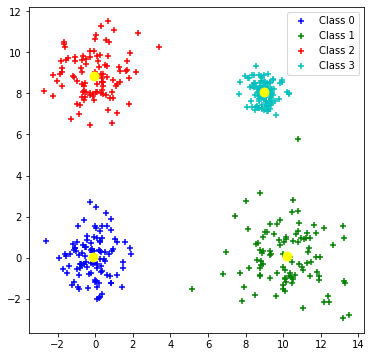

In [4]:
# màu của từng lớp
colors = {0:'b', 1:'g',2:'r',3:'c', 4:'m', 5:'y', 6:'k', 7:'w'} 

# vẽ tập dữ liệu điểm
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(n_classes):
    # tính toán điểm trung tâm từng lớp
    p_center = np.mean(X1[y1==i], axis = 0) 
    print(f'Center {i}: {p_center}')
    # vẽ tập điểm
    plt.scatter(X1[y1==i, 0], X1[y1==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(p_center[0], p_center[1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

### 2. Áp dụng thuật toán phân cụm

Thuật toán k-mean chia tập hợp $N$ mẫu $X_1$ thành $m$ cụm rời rạc $C$ (clusters), mỗi cụm được mô tả bằng giá trị trung bình của các mẫu trong cụm (thường được gọi là trung tâm cụm - centroid).

Thuật toán k-mean hướng tới chọn các centroids sao cho cực tiểu hóa độ đo khoảng cách (intertia) giữa các phần tử trong cụm (within-cluster). Độ đo hay dùng là tổng bình phương khoảng cách theo Euclide distance.

####  2.1. Số cụm m = 4 ngẫu nhiên

In [5]:
m = 4 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, random_state=random_state) # thuật toán kmean
kmeans.fit(X1); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels  = sum(y1 == y_pred) # tính độ chính xác

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

Centers:
[[-4.95411256e-02  8.86110005e+00]
 [ 1.01865125e+01  7.51565800e-03]
 [ 8.97968780e+00  8.02475114e+00]
 [-1.15564255e-01  3.40223244e-02]]
Inertia: 870.6509324177749
Correct Labels: 99 / 400
Accuracy score: 0.25


**Lưu ý**:
+ Intertia là độ đo khoảng cách giữa các phần tử trong cụm. Giá trị càng nhỏ là càng tốt và tiến tới 0 là tốt nhất.
+ Chúng ta chỉ đạt được độ chính xác thấp 25% do đây là mô hình unsupervised (học không giám sát)

Predict: [0 0 2 2 2 2 0 1 3 3 0 3 2 3 3 3 0 1 3 1] ...
Center 0: [-0.04954113  8.86110005]
Center 1: [1.01865125e+01 7.51565800e-03]
Center 2: [8.9796878  8.02475114]
Center 3: [-0.11556425  0.03402232]


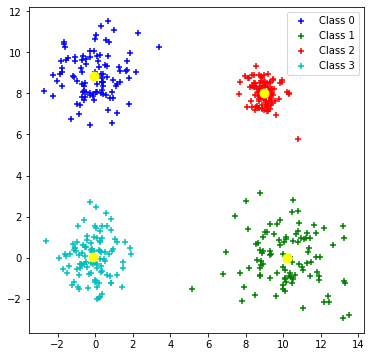

In [6]:
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X1[y_pred==i, 0], X1[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

####  2.2. Số cụm m = 3 ngẫu nhiên

Centers:
[[-0.04954113  8.86110005]
 [ 9.59937239  4.08432411]
 [-0.06354779  0.01847179]]
Inertia: 4135.476824302055
Correct Labels: 99 / 400
Accuracy score: 0.25

Predict: [0 0 1 1 1 1 0 1 2 2 0 2 1 2 2 2 0 1 2 1] ...
Center 0: [-0.04954113  8.86110005]
Center 1: [9.59937239 4.08432411]
Center 2: [-0.06354779  0.01847179]


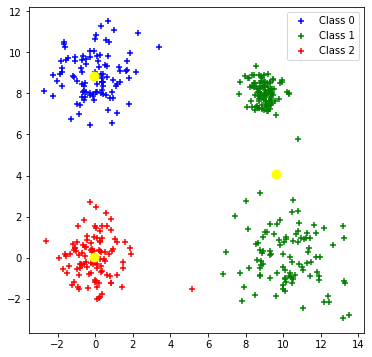

In [7]:
m = 3 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, random_state=random_state) # thuật toán kmean
kmeans.fit(X1); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels = sum(y1 == y_pred)

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

print()
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X1[y_pred==i, 0], X1[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

#### 2.3. Số cụm m = 5 ngẫu nhiên

Centers:
[[-0.11556425  0.03402232]
 [11.25834506 -0.36189194]
 [ 8.9796878   8.02475114]
 [-0.04954113  8.86110005]
 [ 8.90031342  0.45080478]]
Inertia: 717.9588338410931
Correct Labels: 154 / 400
Accuracy score: 0.39

Predict: [3 3 2 2 2 2 3 1 0 0 3 0 2 0 0 0 3 4 0 1] ...
Center 0: [-0.11556425  0.03402232]
Center 1: [11.25834506 -0.36189194]
Center 2: [8.9796878  8.02475114]
Center 3: [-0.04954113  8.86110005]
Center 4: [8.90031342 0.45080478]


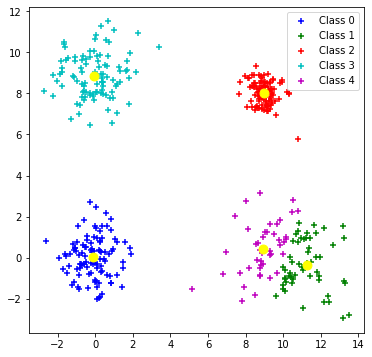

In [8]:
m = 5 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, random_state=random_state) # thuật toán kmean
kmeans.fit(X1); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels = sum(y1 == y_pred)

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

print()
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X1[y_pred==i, 0], X1[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

#### 2.4. Số cụm m = 4 xác định trước

Tập $m=4$ cụm xác định trước lần lượt là $\theta_1 = \left(-2, -2\right)$, $\theta_2 = \left(-2.1, -2.1\right)$, $\theta_3 = \left(-2.0, -2.2\right)$, $\theta_4 = \left(-2.1, -2.2\right)$

Centers:
[[-1.15564255e-01  3.40223244e-02]
 [-4.95411256e-02  8.86110005e+00]
 [ 1.01865125e+01  7.51565800e-03]
 [ 8.97968780e+00  8.02475114e+00]]
Inertia: 870.6509324177749
Correct Labels: 200 / 400
Accuracy score: 0.50

Predict: [1 1 3 3 3 3 1 2 0 0 1 0 3 0 0 0 1 2 0 2] ...
Center 0: [-0.11556425  0.03402232]
Center 1: [-0.04954113  8.86110005]
Center 2: [1.01865125e+01 7.51565800e-03]
Center 3: [8.9796878  8.02475114]


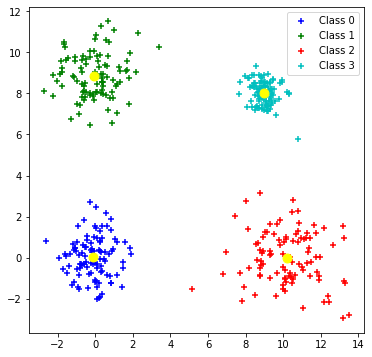

In [9]:
m = 4 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, 
                init = np.array([[-2,-2], [-2.1, -2.1], [-2.0, -2.2], [-2.1,-2.2]]),
                n_init = 1, # chỉ chạy 1 lần k_means
                random_state=random_state) # thuật toán kmean
kmeans.fit(X1); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels = sum(y1 == y_pred)

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

print()
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X1[y_pred==i, 0], X1[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

### 3. Tìm số lượng cụm tối ưu bởi điểm cong (elbow method)

+ Chúng ta thực hiện k-means nhiều lần với k=2, 3, ... 
+ Vẽ đồ thị độ đo khoảng cách giữa các phần tử trong cụm
+ Tìm điểm cong quan trọng của đồ thị

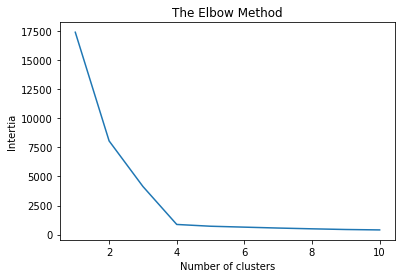

In [10]:
list_intertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i,      # số cluster
                    init = 'k-means++',  # khởi tạo ngẫu nhiên dùng k-means++
                    max_iter = 300,      # số lần lặp trong thuật toán
                    n_init = 10,         # số lần chạy lại k-means và lấy tốt nhất
                    random_state = random_state,
                   )
    kmeans.fit(X1)
    list_intertia.append(kmeans.inertia_)
plt.plot(range(1, 11), list_intertia)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Intertia')
plt.show()

+ Hình trên cho thấy số lượng cluster tối ưu là 4

## Bài 2. Bài tập áp dụng

Áp dụng thuật toán k-means cho tập dữ liệu sau:
+ Tập điểm dữ liệu $X_2$ gồm 400 điểm 2 chiều chứa 4 lớp với số lượng phần tử bằng nhau. Các tập hợp điểm trong lớp tuân theo phân phối Gaussian với means $m_0=\left(0, 0\right)$, $m_1=\left(4, 0\right)$, $m_2=\left(0, 4\right)$, và $m_3=\left(5, 4\right)$ với các covariance matrices tương ứng $S_0=I$, $S_1=1.5I$, $S_2=1.1I$, $S_3=0.5I$.

+ Tập điểm dữ liệu $X_3$ gồm 300 điểm 2 chiều chỉ có 1 lớp dữ liệu với mean $m_1=\left(0, 0\right)$ và $S_1 = I$.

### Lời giải Bài 2.1: Tập dữ liệu X2

- Sinh dữ liệu X2 theo đề bài (400 điểm, 4 lớp Gaussian).
- Chạy k-means với các giá trị k khác nhau để quan sát phân cụm.
- Dùng elbow method để đề xuất số cụm tối ưu.

Thong ke nhan that cua X2:
label
0    100
1    100
2    100
3    100
Name: count, dtype: int64


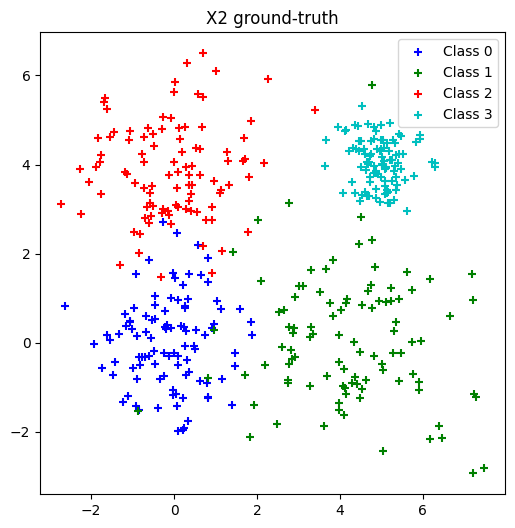

In [5]:
# Sinh dữ liệu X2 theo đề bài
X2, y2 = make_blobs(
    n_samples=400,
    centers=[[0, 0], [4, 0], [0, 4], [5, 4]],
    cluster_std=[1.0, 1.5, 1.1, 0.5],
    random_state=random_state,
)

df_x2 = pd.DataFrame(X2, columns=["x", "y"])
df_x2["label"] = y2

print("Thong ke nhan that cua X2:")
print(df_x2["label"].value_counts().sort_index())

palette = ["b", "g", "r", "c", "m", "y", "k"]
plt.figure(figsize=(6, 6))
for i in sorted(np.unique(y2)):
    plt.scatter(X2[y2 == i, 0], X2[y2 == i, 1], marker="+", c=palette[i % len(palette)], label=f"Class {i}")
plt.title("X2 ground-truth")
plt.legend()
plt.show()

In [6]:
def run_kmeans_and_plot(X, y_true=None, k=4, title_prefix="X"):
    model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    y_pred = model.fit_predict(X)

    print(f"{title_prefix} - k = {k}")
    print(f"Inertia: {model.inertia_:.3f}")
    print("Centers:")
    print(model.cluster_centers_)

    if y_true is not None:
        # Nhan cua k-means co the bi hoan vi nen gia tri nay chi de tham khao.
        rough_match = np.mean(y_true == y_pred)
        print(f"Rough label match (tham khao): {rough_match:.2%}")

    palette = ["b", "g", "r", "c", "m", "y", "k"]
    plt.figure(figsize=(6, 6))
    for i in range(k):
        plt.scatter(
            X[y_pred == i, 0],
            X[y_pred == i, 1],
            marker="+",
            c=palette[i % len(palette)],
            label=f"Cluster {i}",
        )
        plt.scatter(
            model.cluster_centers_[i, 0],
            model.cluster_centers_[i, 1],
            marker="o",
            c="yellow",
            s=90,
            edgecolors="black",
        )

    plt.title(f"{title_prefix} - KMeans k={k}")
    plt.legend()
    plt.show()
    return model, y_pred


def elbow_curve(X, k_min=1, k_max=10, title="Elbow"):
    inertias = []
    ks = list(range(k_min, k_max + 1))
    for k in ks:
        model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        model.fit(X)
        inertias.append(model.inertia_)

    plt.figure(figsize=(6, 4))
    plt.plot(ks, inertias, marker="o")
    plt.title(title)
    plt.xlabel("k")
    plt.ylabel("Inertia")
    plt.grid(alpha=0.3)
    plt.show()

    print("Inertia theo k:")
    for k, val in zip(ks, inertias):
        print(f"k={k}: {val:.3f}")
    return ks, inertias

X2 - k = 3
Inertia: 1490.207
Centers:
[[ 4.33791065 -0.16546659]
 [-0.13394564  1.81465404]
 [ 4.73696508  4.09220328]]
Rough label match (tham khao): 3.75%


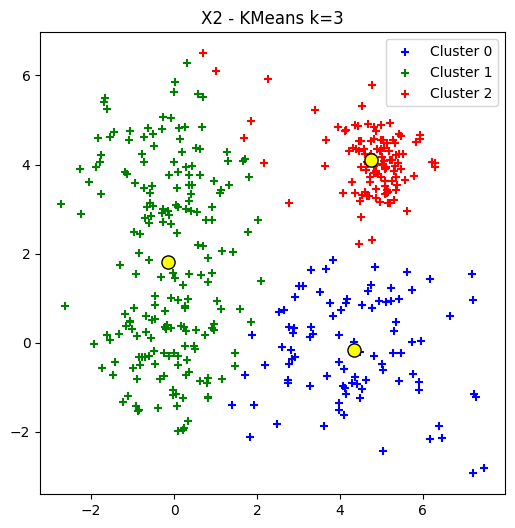

X2 - k = 4
Inertia: 746.481
Centers:
[[-0.02567875 -0.06066094]
 [ 4.91382944  4.02072054]
 [-0.02935929  3.82484948]
 [ 4.51504729 -0.10687236]]
Rough label match (tham khao): 49.25%


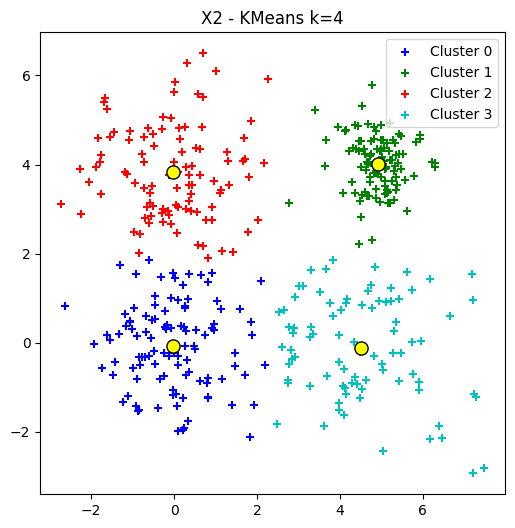

X2 - k = 5
Inertia: 634.749
Centers:
[[-0.02935929  3.82484948]
 [ 4.91382944  4.02072054]
 [-0.21456583 -0.03910594]
 [ 5.3145626  -0.33149043]
 [ 2.91830288  0.12688156]]
Rough label match (tham khao): 3.00%


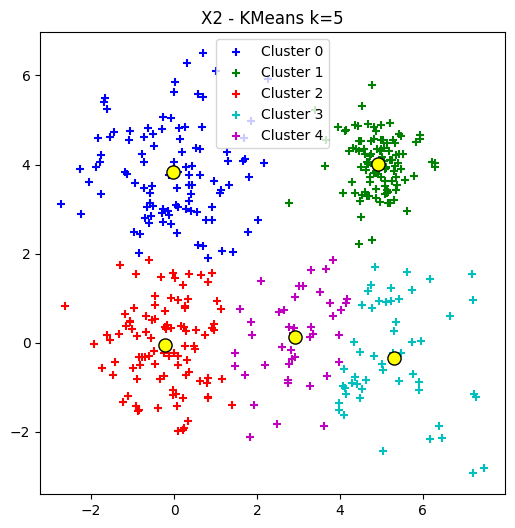

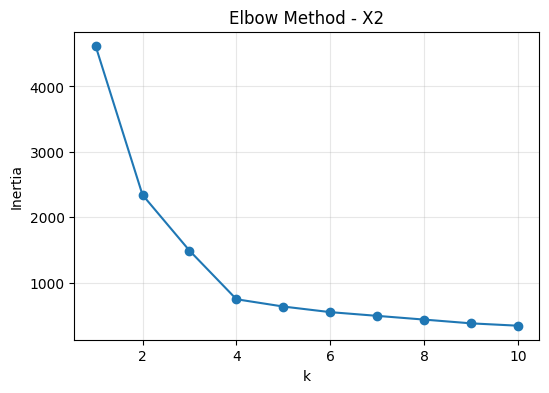

Inertia theo k:
k=1: 4622.963
k=2: 2342.178
k=3: 1490.207
k=4: 746.481
k=5: 634.749
k=6: 549.235
k=7: 492.339
k=8: 435.354
k=9: 377.791
k=10: 341.751
=> So cum de xuat cho X2: k = 4 (du lieu tao ra tu 4 tam).


In [7]:
# Chay voi mot so gia tri k cho X2
_ = run_kmeans_and_plot(X2, y_true=y2, k=3, title_prefix="X2")
_ = run_kmeans_and_plot(X2, y_true=y2, k=4, title_prefix="X2")
_ = run_kmeans_and_plot(X2, y_true=y2, k=5, title_prefix="X2")

# Elbow cho X2
ks_x2, inertias_x2 = elbow_curve(X2, k_min=1, k_max=10, title="Elbow Method - X2")
print("=> So cum de xuat cho X2: k = 4 (du lieu tao ra tu 4 tam).")

### Lời giải Bài 2.2: Tập dữ liệu X3

- Sinh dữ liệu X3 gồm 300 điểm từ 1 Gaussian duy nhất tâm (0, 0).
- Chạy k-means với k=1,2,3 để quan sát hiện tượng chia tách cưỡng bức khi chọn k lớn hơn số cụm thật.
- Dùng elbow method để kiểm tra số cụm phù hợp.

Thong ke nhan that cua X3:
label
0    300
Name: count, dtype: int64


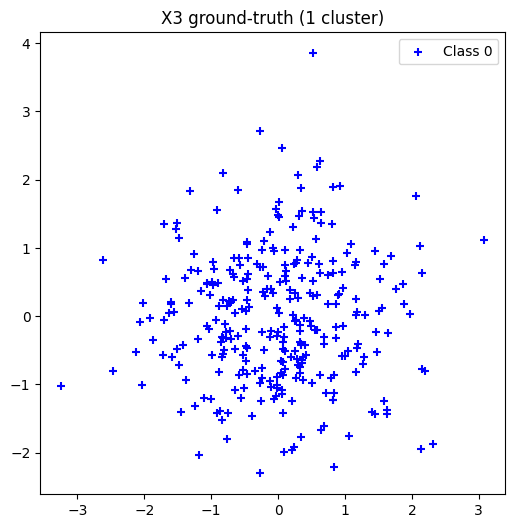

X3 - k = 1
Inertia: 566.144
Centers:
[[-0.01078431 -0.01625424]]
Rough label match (tham khao): 100.00%


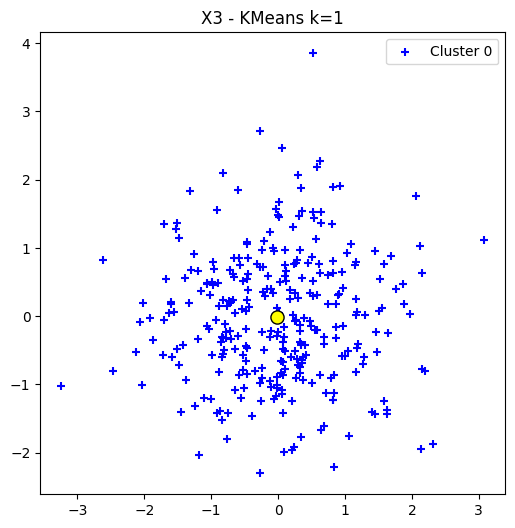

X3 - k = 2
Inertia: 381.425
Centers:
[[-0.56196396  0.57905573]
 [ 0.50483537 -0.57315711]]
Rough label match (tham khao): 48.33%


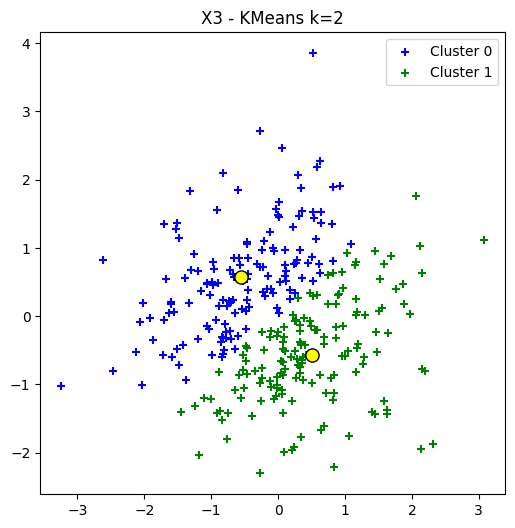

X3 - k = 3
Inertia: 246.949
Centers:
[[ 0.36797023 -0.8491918 ]
 [-1.08711139  0.07267384]
 [ 0.58561699  0.92575045]]
Rough label match (tham khao): 38.33%


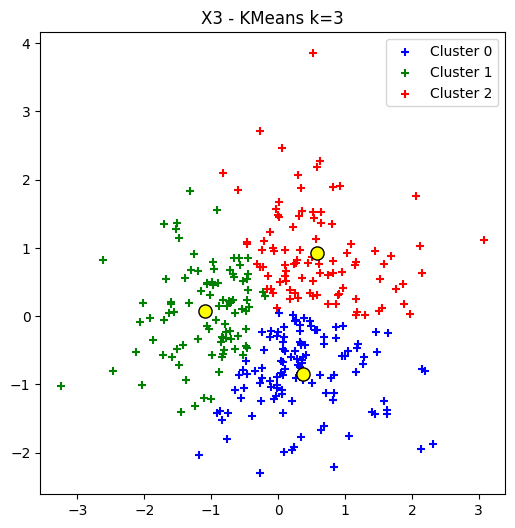

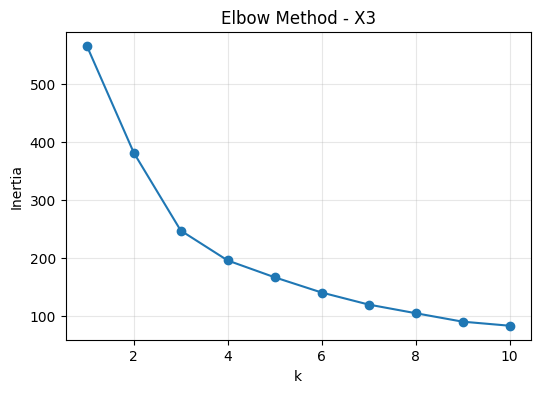

Inertia theo k:
k=1: 566.144
k=2: 381.425
k=3: 246.949
k=4: 195.268
k=5: 166.233
k=6: 139.930
k=7: 119.150
k=8: 104.252
k=9: 89.620
k=10: 82.596
=> So cum de xuat cho X3: k = 1.


In [8]:
# Sinh du lieu X3: 300 diem, 1 cum Gaussian
X3, y3 = make_blobs(
    n_samples=300,
    centers=[[0, 0]],
    cluster_std=[1.0],
    random_state=random_state,
)

df_x3 = pd.DataFrame(X3, columns=["x", "y"])
df_x3["label"] = y3

print("Thong ke nhan that cua X3:")
print(df_x3["label"].value_counts().sort_index())

plt.figure(figsize=(6, 6))
plt.scatter(X3[:, 0], X3[:, 1], marker="+", c="b", label="Class 0")
plt.title("X3 ground-truth (1 cluster)")
plt.legend()
plt.show()

_ = run_kmeans_and_plot(X3, y_true=y3, k=1, title_prefix="X3")
_ = run_kmeans_and_plot(X3, y_true=y3, k=2, title_prefix="X3")
_ = run_kmeans_and_plot(X3, y_true=y3, k=3, title_prefix="X3")

ks_x3, inertias_x3 = elbow_curve(X3, k_min=1, k_max=10, title="Elbow Method - X3")
print("=> So cum de xuat cho X3: k = 1.")

# Kết thúc